In [3]:
import logging
import sys
logger = logging.getLogger('cosipy')
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(sys.stdout))
from cosipy.util import fetch_wasabi_file

# dependencies for response
import numpy as np
import astropy.units as u
from astropy.units import Quantity
from astropy.coordinates import SkyCoord, cartesian_to_spherical, Galactic
from astropy.io import fits
from astropy.time import Time
from astropy.table import Table
import matplotlib.pyplot as plt

# dependencies for plotting mollweide projections
from mhealpy import HealpixMap, HealpixBase
import healpy as hp
import pandas as pd
from pathlib import Path

# This is cosi.response
from scoords import Attitude, SpacecraftFrame
from cosipy.response import FullDetectorResponse, DetectorResponse
from cosipy.spacecraftfile import SpacecraftFile
from cosipy import test_data
from histpy import Histogram, HealpixAxis, Axis, Axes
import gc

# This is cosi.BinnedData
from cosipy import BinnedData, UnBinnedData
# this is for fitting and forward folding (#3ML is needed for spectral modeling)
from threeML import Model, Powerlaw
from astromodels import Band


# This is cosi_image_deconvolution
from cosipy.image_deconvolution import SpacecraftAttitudeExposureTable, CoordsysConversionMatrix, DataIF_COSI_DC2, ImageDeconvolution
from cosipy.util import fetch_wasabi_file
from cosipy.ts_map.TSMap import TSMap

# dependencies for data handling
import shutil
import os
from hashlib import md5

In [6]:
# ----------------------------------------------------------------------------------------------------------------------------
path_to_Source = "COSI-SMEX/DC3/Data/Sources/"
# Source file
Fe60_Source_file= "60Fe_NE2001_3months_unbinned_data_filtered_with_SAAcut.fits.gz"

# ----------------------------------------------------------------------------------------------------------------------------
path_to_Ori = "COSI-SMEX/DC3/Data/Orientation/"
#oritnation file
ori_file = "DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"

# ----------------------------------------------------------------------------------------------------------------------------
# response file
response_file_Fe60_high = "Response60FeHigh.o4.e1329_1336.s10201526728102.m1287.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5.zip"
response_file_Fe60_low = "Response60FeLow.o4.e1170_1176.s9552269354945.m1188.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5.zip"

# ----------------------------------------------------------------------------------------------------------------------------
path_to_bkg= "COSI-SMEX/DC3/Data/Backgrounds/Ge/" 
path_to_bkg_binned= "COSI-SMEX/DC3/Data/Backgrounds/Ge/Binned_BG_Files/"
#background files
albedo_bkg_file = "AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
Fe60_high_bkg_file = "Total_BG_3months_binned_for_Fe60High_filtered_with_SAAcut.hdf5"
Fe60_low_bkg_file = "Total_BG_3months_binned_for_Fe60Low_filtered_with_SAAcut.hdf5"



# #----------------------------------------------------------------------------------------------------------------------------
# # for some reason the source and bkg file are remained zipped
# # Source file
# fetch_wasabi_file(path_to_Source + Fe60_Source_file, unzip=True, checksum='21e65cd5684fd2671be983368e0908a0')

# #----------------------------------------------------------------------------------------------------------------------------
# #Background files
# # fetch_wasabi_file(path_to_bkg + albedo_bkg_file)
# fetch_wasabi_file((path_to_bkg_binned + Fe60_high_bkg_file))
# # fetch_wasabi_file((path_to_bkg_binned + Fe60_low_bkg_file))

# #----------------------------------------------------------------------------------------------------------------------------
# # ONLY RESPONSE FILE ARE UNZIPPED

# #response file
# fetch_wasabi_file("COSI-SMEX/DC3/Data/Responses/" + response_file_Fe60_high)
# # fetch_wasabi_file("COSI-SMEX/DC3/Data/Responses/" + response_file_Fe60_low)

# # Use unzip for .zip files, not gunzip
# os.system('unzip -o ' + response_file_Fe60_high)
# # os.system('unzip -o ' + response_file_Fe60_low)


# #----------------------------------------------------------------------------------------------------------------------------
#oritnation file
# fetch_wasabi_file(path_to_Ori + ori_file)


data_path = "data/"

# psichi
# 3720

binning data...
binning data...
Time unit: s
Time unit: s
Em unit: keV
Em unit: keV
Phi unit: deg
Phi unit: deg
PsiChi unit: None
PsiChi unit: None


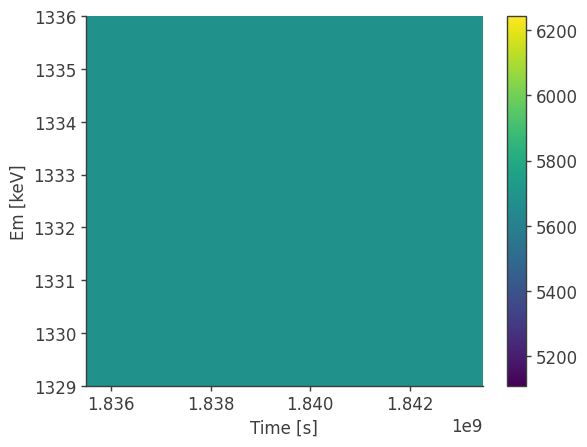

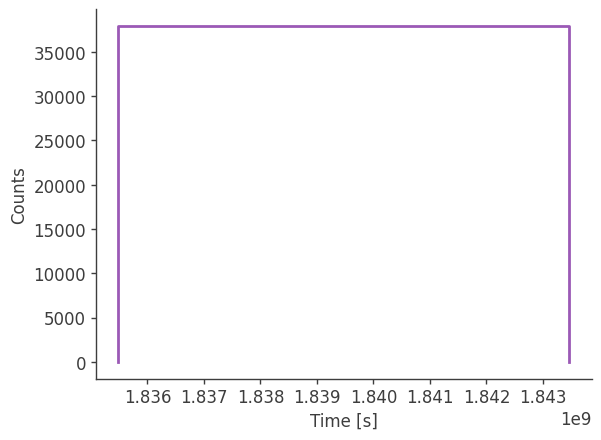

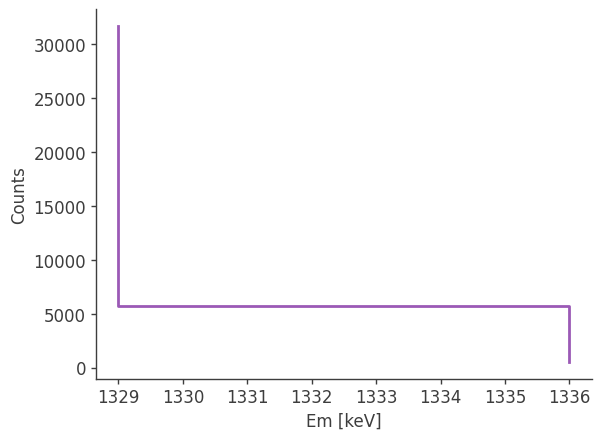

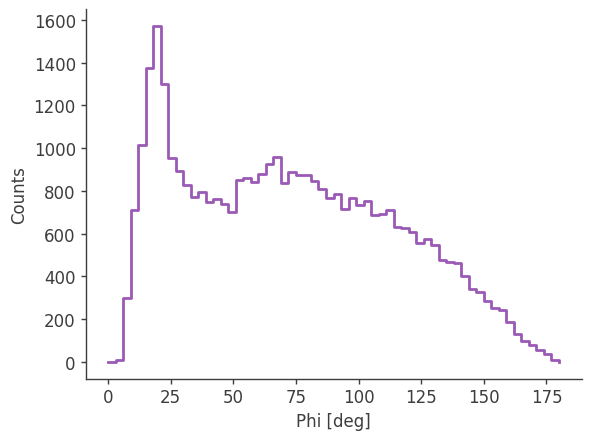

plotting psichi map in galactic...
plotting psichi map in galactic...


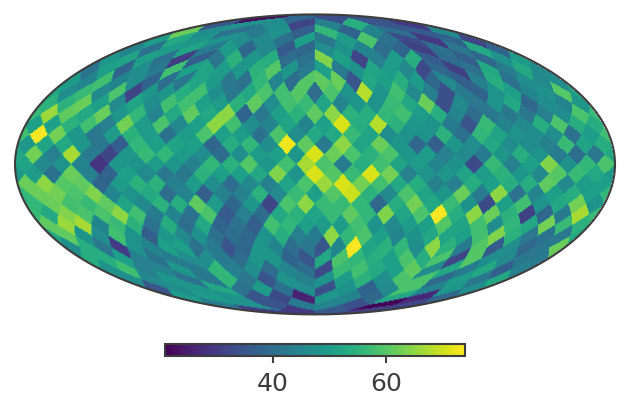

In [35]:
%matplotlib inline
plot = 1
source = BinnedData("inputs.yaml")
# this one is used when
source.get_binned_data(unbinned_data = data_path + Fe60_Source_file, make_binning_plots=plot, show_plots=plot)

In [36]:
binned_bkg = Histogram.open(data_path + Fe60_high_bkg_file)

In [37]:
signal = source.binned_data.to_dense()  
bkg = binned_bkg.to_dense()  
event = signal + bkg

ValueError: Axes mismatch

In [14]:
event.write(data_path + "Fe60_galactic_event_binned.hdf5", overwrite = True)
signal.write(data_path + "Fe60_galactic_singal_binned.hdf5", overwrite = True)
event.write(data_path + "Fe60_galactic_bkg_binned.hdf5", overwrite = True)

In [16]:
binned_event = Histogram.open(data_path + "Fe60_galactic_event_binned.hdf5")
binned_bkg = Histogram.open(data_path + Fe60_high_bkg_file)

response_path = data_path + response_file_Fe60_high.replace(".zip", "")
response = FullDetectorResponse.open(response_path)

ccm = CoordsysConversionMatrix.open(data_path + "ccm_Fe60_timebinning.hdf5")
ori = SpacecraftFile.parse_from_file(data_path + ori_file)

# exposure_table = SpacecraftAttitudeExposureTable.from_orientation(ori, nside = 16, start = None, stop = None)

In [17]:
# Find spatial axes (HealpixAxis) and show their coordinate systems
print(binned_bkg.axes['PsiChi'].coordsys) 
print(binned_event.axes['PsiChi'].coordsys)


print(response.axes[4].coordsys)
print(response.axes[0].coordsys)

<Galactic Frame>
<Galactic Frame>
<SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>
<SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>


In [18]:
%%time

data_interface = DataIF_COSI_DC2.load(name = "Fe60",
                                      event_binned_data = binned_event,
                                      dict_bkg_binned_data = {"Fe60 High": binned_bkg},
                                      rsp = response,
                                      coordsys_conv_matrix=ccm)

Loading the response matrix onto your computer memory...
Loading the response matrix onto your computer memory...
Finished
Finished
... checking the axis Time of the event and background files...
... checking the axis Time of the event and background files...
    --> pass (edges)
    --> pass (edges)
... checking the axis Em of the event and background files...
... checking the axis Em of the event and background files...
    --> pass (edges)
    --> pass (edges)
... checking the axis Phi of the event and background files...
... checking the axis Phi of the event and background files...
    --> pass (edges)
    --> pass (edges)
... checking the axis PsiChi of the event and background files...
... checking the axis PsiChi of the event and background files...
    --> pass (edges)
    --> pass (edges)
...checking the axis Em of the event and response files...
...checking the axis Em of the event and response files...
    --> pass (edges)
    --> pass (edges)
...checking the axis Phi of th

In [19]:
print(response.axes.labels)


['NuLambda' 'Ei' 'Em' 'Phi' 'PsiChi']


In [20]:
parameter_filepath = "imagedeconvolution_Fe60.yml"

In [21]:
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([data_interface])
image_deconvolution.read_parameterfile(parameter_filepath)


In [22]:
image_deconvolution.initialize()

#### Initialization Starts ####
#### Initialization Starts ####
<< Instantiating the model class AllSkyImage >>
<< Instantiating the model class AllSkyImage >>
---- parameters ----
---- parameters ----
coordinate: galactic
energy_edges:
  unit: keV
  value:
  - 1329.0
  - 1336.0
nside: 16
scheme: ring
unit: cm-2 s-1 sr-1

coordinate: galactic
energy_edges:
  unit: keV
  value:
  - 1329.0
  - 1336.0
nside: 16
scheme: ring
unit: cm-2 s-1 sr-1

<< Setting initial values of the created model object >>
<< Setting initial values of the created model object >>
---- parameters ----
---- parameters ----
algorithm: flat
parameter:
  unit: cm-2 s-1 sr-1
  value:
  - 1e-4

algorithm: flat
parameter:
  unit: cm-2 s-1 sr-1
  value:
  - 1e-4

<< Registering the deconvolution algorithm >>
<< Registering the deconvolution algorithm >>
Gaussian filter with FWHM of 0.5 deg will be applied to delta images ...
Gaussian filter with FWHM of 0.5 deg will be applied to delta images ...
---- parameters ----
---

In [23]:
print(image_deconvolution._check_model_response_consistency())


True


In [24]:
image_deconvolution.run_deconvolution()

#### Image Deconvolution Starts ####
#### Image Deconvolution Starts ####
<< Initialization >>
<< Initialization >>
The response weighting filter was calculated.
The response weighting filter was calculated.
The expected count histograms were calculated with the initial model map.
The expected count histograms were calculated with the initial model map.


  0%|          | 0/30 [00:00<?, ?it/s]

## Iteration 1/30 ##
## Iteration 1/30 ##
<< Pre-processing >>
<< Pre-processing >>
<< E-step >>
<< E-step >>
<< M-step >>
<< M-step >>
<< Post-processing >>
<< Post-processing >>



WARNING RuntimeWarning: invalid value encountered in divide



<< Registering Result >>
<< Registering Result >>
  alpha: 1.0
  alpha: 1.0
  background_normalization: {'Fe60 High': 0.8539088740794731}
  background_normalization: {'Fe60 High': 0.8539088740794731}
  loglikelihood: [26189.328640356078]
  loglikelihood: [26189.328640356078]
<< Checking Stopping Criteria >>
<< Checking Stopping Criteria >>
--> Continue
--> Continue
## Iteration 2/30 ##
## Iteration 2/30 ##
<< Pre-processing >>
<< Pre-processing >>
<< E-step >>
<< E-step >>
<< M-step >>
<< M-step >>
<< Post-processing >>
<< Post-processing >>


...

<< Registering Result >>
<< Registering Result >>
  alpha: 1.0
  alpha: 1.0
  background_normalization: {'Fe60 High': 1.0001790345558197}
  background_normalization: {'Fe60 High': 1.0001790345558197}
  loglikelihood: [35148.07132089656]
  loglikelihood: [35148.07132089656]
<< Checking Stopping Criteria >>
<< Checking Stopping Criteria >>
--> Continue
--> Continue
## Iteration 29/30 ##
## Iteration 29/30 ##
<< Pre-processing >>
<< Pre-processing >>
<< E-step >>
<< E-step >>
<< M-step >>
<< M-step >>
<< Post-processing >>
<< Post-processing >>



WARNING RuntimeWarning: invalid value encountered in divide



<< Registering Result >>
<< Registering Result >>
  alpha: 1.0
  alpha: 1.0
  background_normalization: {'Fe60 High': 1.0002211008564839}
  background_normalization: {'Fe60 High': 1.0002211008564839}
  loglikelihood: [35150.07189896173]
  loglikelihood: [35150.07189896173]
<< Checking Stopping Criteria >>
<< Checking Stopping Criteria >>
--> Continue
--> Continue
## Iteration 30/30 ##
## Iteration 30/30 ##
<< Pre-processing >>
<< Pre-processing >>
<< E-step >>
<< E-step >>
<< M-step >>
<< M-step >>
<< Post-processing >>
<< Post-processing >>



WARNING RuntimeWarning: invalid value encountered in divide



<< Registering Result >>
<< Registering Result >>
  alpha: 1.0
  alpha: 1.0
  background_normalization: {'Fe60 High': 1.0002542001847754}
  background_normalization: {'Fe60 High': 1.0002542001847754}
  loglikelihood: [35152.001072184066]
  loglikelihood: [35152.001072184066]
<< Checking Stopping Criteria >>
<< Checking Stopping Criteria >>
--> Stop
--> Stop
<< Finalization >>
<< Finalization >>
#### Image Deconvolution Finished ####
#### Image Deconvolution Finished ####


In [25]:
image_deconvolution.results

[{'iteration': 1,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x738adbf537f0>,
  'delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x738adbf538b0>,
  'processed_delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x738adbf51e40>,
  'background_normalization': {'Fe60 High': 0.8539088740794731},
  'alpha': 1.0,
  'loglikelihood': [26189.328640356078]},
 {'iteration': 2,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x738adbf76b60>,
  'delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x738adbf76c20>,
  'processed_delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x738adbf74550>,
  'background_normalization': {'Fe60 High': 0.8867302322554442},
  'alpha': 1.0,
  'loglikelihood': [28952.658419593005]},
 {'iteration': 3,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x738adbf756c0>,
  'delta_model': <cosipy.image_deconvolu

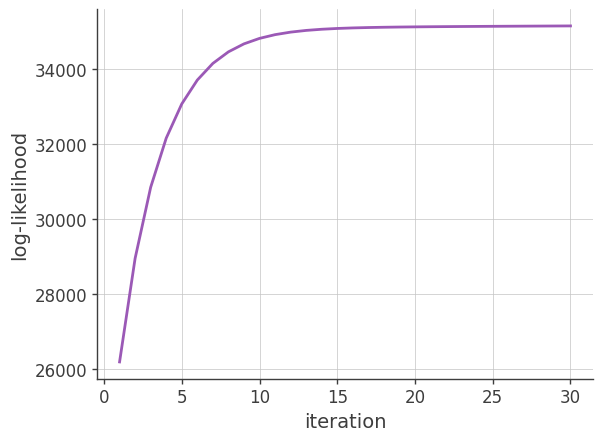

In [26]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['loglikelihood'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("log-likelihood")
plt.show()

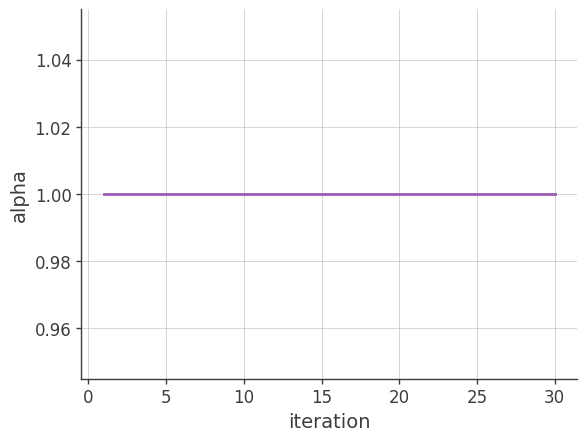

In [27]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['alpha'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("alpha")
plt.show()

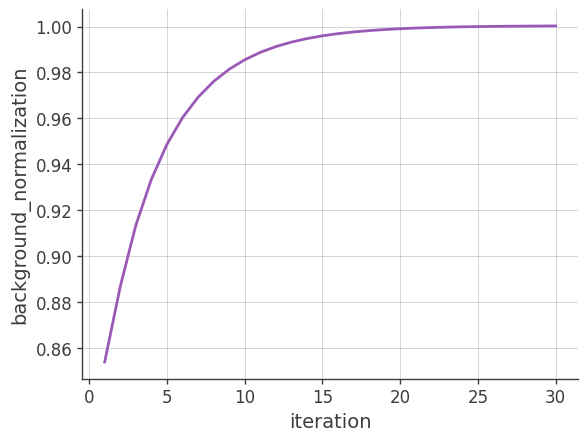

In [28]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['background_normalization']['Fe60 High'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("background_normalization")
plt.show()

In [29]:
def plot_reconstructed_image(result, source_position = None): # source_position should be (l,b) in degrees
    iteration = result['iteration']
    image = result['model']

    for energy_index in range(image.axes['Ei'].nbins):
        map_healpxmap = HealpixMap(data = image[:,energy_index], unit = image.unit)

        _, ax = map_healpxmap.plot('mollview')        
        
        _.colorbar.set_label(str(image.unit))
        
        if source_position is not None:
            ax.scatter(source_position[0]*u.deg, source_position[1]*u.deg, transform=ax.get_transform('world'), color = 'red')

        plt.title(label = f"iteration = {iteration}, energy_index = {energy_index} ({image.axes['Ei'].bounds[energy_index][0]}-{image.axes['Ei'].bounds[energy_index][1]})")

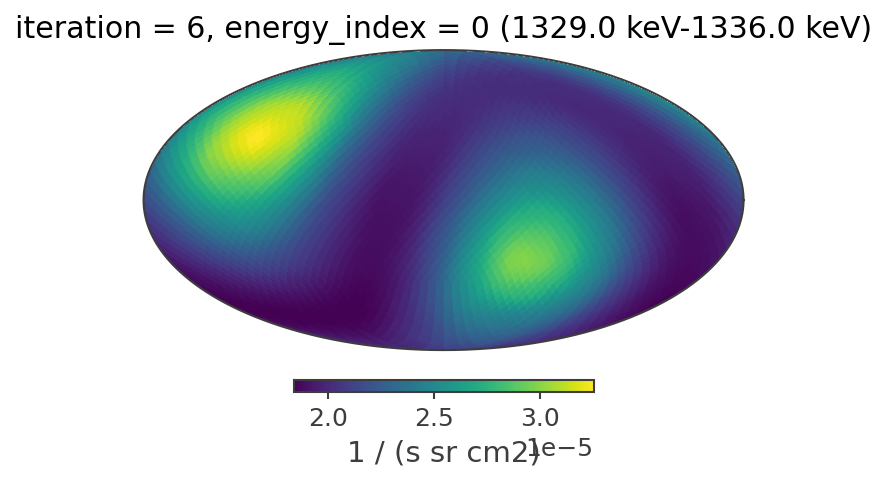

In [34]:
iteration = 5


plot_reconstructed_image(image_deconvolution.results[iteration])